<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/ML/Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

cdf = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{cdf['churn'].mean():.1%}")
cdf.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [3]:
cdf.columns

Index(['tenure', 'monthly', 'support', 'age', 'churn'], dtype='object')

In [4]:
from sklearn.model_selection import train_test_split

X = cdf[['tenure', 'monthly', 'support', 'age']]
y = cdf['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Навчальна вибірка:', X_train.shape[0], 'клієнтів')
print('Тестова вибірка:', X_test.shape[0], 'клієнтів')

Навчальна вибірка: 960 клієнтів
Тестова вибірка: 240 клієнтів


### Decision three

In [5]:
from sklearn.tree import DecisionTreeClassifier

model_three = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE,
)

model_three.fit(X_train, y_train)
y_pred = model_three.predict(X_test)

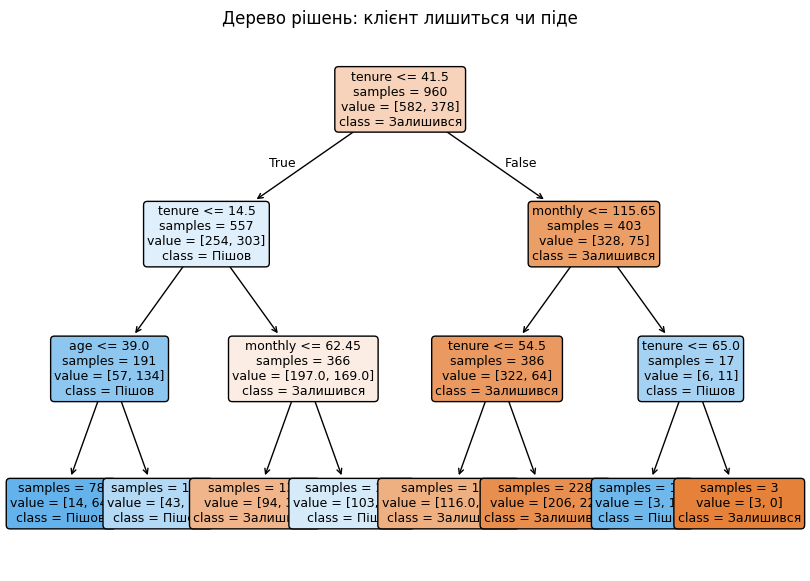

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    model_three,
    feature_names=X.columns,
    class_names=['Залишився', 'Пішов'],
    filled=True,rounded=True, fontsize=9, impurity=False
)

plt.title('Дерево рішень: клієнт лишиться чи піде');

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred) * 100
print(f'Accuracy = {acc:.2f}%\n')

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=['Насправді залишилися', 'Насправді пішли'],
    columns=['Передбачено залишилися', 'Передбачено пішли']
)

print('Матриця плутанини:')
display(df_cm)

print('\nДетальний звіт:')
print(classification_report(y_test, y_pred, target_names=['Залишилися', 'Пішли']))

Accuracy = 59.17%

Матриця плутанини:


,Передбачено залишилися,Передбачено пішли
Насправді залишилися,85,61
Насправді пішли,37,57



Детальний звіт:
              precision    recall  f1-score   support

  Залишилися       0.70      0.58      0.63       146
       Пішли       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



### Random Forest

In [8]:
# from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test)

print(f'Одне дерево: accuracy = {accuracy_score(y_test, y_pred):.2%}')
print(f'Цілий ліс: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}')

Одне дерево: accuracy = 59.17%
Цілий ліс: accuracy = 64.58%


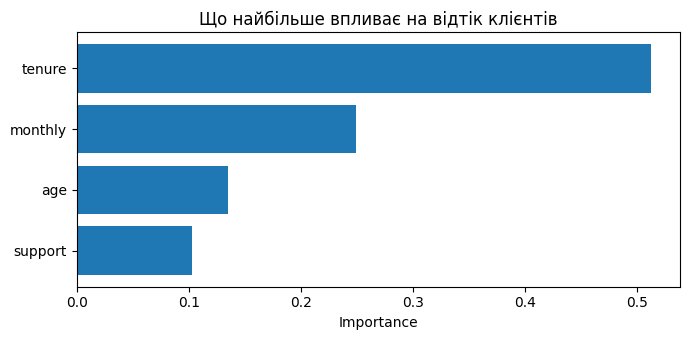

,features,importances
2,support,0.103
3,age,0.135
1,monthly,0.249
0,tenure,0.513


In [9]:
importances = pd.DataFrame({
    'features':X.columns,
    'importances':model_forest.feature_importances_.round(3)
}).sort_values('importances')

plt.figure(figsize=(7, 3.5))
plt.barh(importances['features'], importances['importances'])

plt.xlabel('Importance')
plt.title('Що найбільше впливає на відтік клієнтів')
plt.tight_layout()
plt.show()

importances

### Прогнозування

In [10]:
new_client = pd.DataFrame([{
    'tenure':3,
    'monthly':95,
    'support':5,
    'age':25
}])

new_client

,tenure,monthly,support,age
0,3,95,5,25


In [13]:
print(f'Ймовірність відтоку: {model_forest.predict_proba(new_client)[0, 1]:.2%}')
# print(f'Рішення: {"Піде" if model_forest.predict(new_client)[0] == 1 else "Залишиться"}')
print(f'Рішення: {"Піде" if model_forest.predict(new_client)[0] else "Залишиться"}')

print('\n---------------')
print(f'Вірогідність результату: {accuracy_score(y_test, y_pred_rf):.2%}')

Ймовірність відтоку: 88.66%
Рішення: Піде

---------------
Вірогідність результату: 64.58%


In [14]:
pred_model = model_forest.predict(new_client)[0]
# 1 or 0
# 1 (True) or 0 (False)
if pred_model:
    print('Піде')
else:
    print('Залишиться')


Піде
